# Machine Learning con Scikit-learn
Se usará un Pipeline de Scikit-Learn que procese las variables categóricas (como el nombre del servicio) y entrene un Random Forest Regressor.

## Importar librerías y cargar datos

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos limpios
df = pd.read_csv('../data/processed/uber_lyft_cleaned.csv')

# Hacemos la muestra dinámica para evitar errores si el dataset es menor a 100k
tamano_muestra = min(100000, len(df))
df_model = df.sample(tamano_muestra, random_state=42)

print(f"Dataset total: {len(df)} filas")
print(f"Datos utilizados para modelado: {df_model.shape[0]} filas")

Dataset total: 635242 filas
Datos utilizados para modelado: 100000 filas


# Preparación de Variables ($X$ e $y$)

In [2]:
# Variables predictoras (Features)
# Usaremos distancia, multiplicador de tarifa, hora, temperatura y el tipo de servicio
X = df_model[['distance', 'surge_multiplier', 'hour', 'temp', 'name']]

# Variable objetivo (Target)
y = df_model['price']

# Separar en datos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} filas | Prueba: {X_test.shape[0]} filas")

Entrenamiento: 80000 filas | Prueba: 20000 filas


Creación del Pipeline y Entrenamiento
Insight para tu documentación: Usar un Pipeline demuestra buenas prácticas de ingeniería de software aplicadas a Data Science.

In [4]:
# 1. Transformador para variables categóricas ('name' contiene UberX, Lyft XL, etc.)
categorical_features = ['name']
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# 2. Preprocesador que aplica la transformación solo a la columna categórica
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Deja las variables numéricas intactas
)

# 3. Crear el Pipeline completo con un Random Forest Regressor
# Limitamos la profundidad (max_depth) para que entrene rápido
modelo_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1))
])

# 4. ¡Entrenar el modelo!
print("Entrenando el modelo Random Forest... (esto puede tomar unos segundos)")
modelo_rf.fit(X_train, y_train)
print("¡Entrenamiento completado!")

Entrenando el modelo Random Forest... (esto puede tomar unos segundos)
¡Entrenamiento completado!


# Evaluación del Modelo
Aquí calculamos el $RMSE$ (Raíz del Error Cuadrático Medio) y el $R^2$ para medir la precisión.

Rendimiento del Modelo:
RMSE (Error promedio en dólares): $1.92
R^2 (Varianza explicada): 0.96


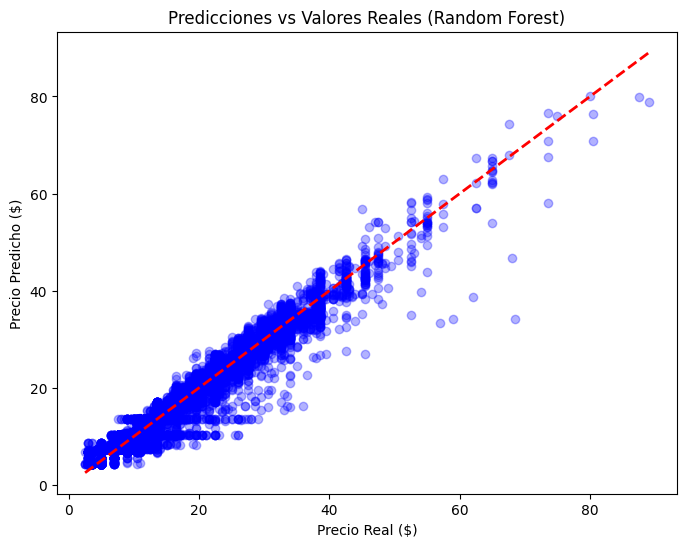

In [5]:
# Hacer predicciones con los datos de prueba
y_pred = modelo_rf.predict(X_test)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Rendimiento del Modelo:")
print(f"RMSE (Error promedio en dólares): ${rmse:.2f}")
print(f"R^2 (Varianza explicada): {r2:.2f}")

# Gráfico de Predicciones vs Valores Reales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')
plt.title('Predicciones vs Valores Reales (Random Forest)')
plt.show()